# **Modelo LSTM Bidireccional + LIME para Detección de Fake News**

Este notebook implementa una red neuronal recurrente (BiLSTM) para clasificar noticias en español como **reales** (`0`) o **falsas** (`1`).

## **1. Importación de Librerías**

In [37]:
import os
import re
import pickle
import warnings
import unicodedata
from html import unescape

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **2. Carga del Dataset Preprocesado**
Cargamos el CSV generado por `Data/preprocesado.py`. Usaremos la columna **`text_dl`** (limpieza suave: sin lematización, preserva contexto semántico) y **`label`** (0=Real, 1=Fake).

In [38]:
DATA_PATH = "../Data/dataset_preprocesado_binario.csv"

df = pd.read_csv(DATA_PATH)
print(f"Registros totales: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nDistribución de clases:")
print(df['label'].value_counts())
print(f"\nRatio Fake/Real: {df['label'].mean():.2%}")
df[['text_dl', 'label']].head()

Registros totales: 62361
Columnas: ['ID', 'Title', 'Content', 'State', 'Dataset', 'label', 'full_text', 'text_ml', 'text_dl', 'text_beto', 'num_chars', 'num_words', 'num_exclamaciones', 'num_interrogaciones', 'num_urls', 'num_emails', 'num_mayusculas', 'num_digitos', 'num_ellipsis', 'num_quotes']

Distribución de clases:
label
1    35186
0    27175
Name: count, dtype: int64

Ratio Fake/Real: 56.42%


,text_dl,label
0,el suceso ha tenido lugar en brasil. un adoles...,1
1,"""la quimioterapia mata a la gente y no al cánc...",1
2,los cubos de caldo para cocinar son veneno par...,1
3,megaterremoto en los próximos días alineación ...,1
4,qué injusticia! el perro que defendió su casa ...,1


### **2.1 Limpieza y Validación**
Eliminamos registros con texto vacío o nulo y verificamos la integridad del dataset.

In [39]:
# Eliminar nulos y vacíos
df = df.dropna(subset=['text_dl', 'label']).copy()
df = df[df['text_dl'].str.strip() != ''].copy()
df['label'] = df['label'].astype(int)

texts = df['text_dl'].values
labels = df['label'].values

print(f"Registros válidos: {len(texts)}")
print(f"Ejemplo de texto DL:")
print(texts[0][:200])

Registros válidos: 62361
Ejemplo de texto DL:
el suceso ha tenido lugar en brasil. un adolescente de numero años murió después de masturbarse numero veces seguidas. sin parar. según el informe de las autoridades el joven comenzó a medianoche y se


## **3. División del Dataset (Train / Val / Test)**

Dividimos en tres conjuntos con **estratificación** para mantener la proporción de clases:
- **Train (70%)**: Para que la red aprenda los patrones.
- **Validación (10%)**: Para monitorizar el rendimiento durante el entrenamiento (Early Stopping).
- **Test (20%)**: Evaluación final a ciegas (datos que el modelo jamás ha visto).

In [40]:
# Primero dividimos los textos crudos para evitar que el Tokenizer vea los datos de Test
TEST_SIZE = 0.2
VAL_SIZE  = 0.1

X_raw = df['text_dl'].values
y = df['label'].values

# Primera división: Train+Val (80%) vs Test (20%)
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

# Segunda división: Train (70%) vs Val (10%)
val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw, y_train_val, test_size=val_relative_size, random_state=42, stratify=y_train_val
)

## **4. Construcción del Vocabulario (Tokenizer)**

Creamos un diccionario que asigna un **ID numérico** a cada palabra. Limitamos el vocabulario a las `MAX_VOCAB` palabras más frecuentes. El token `<OOV>` (Out-Of-Vocabulary) se reserva para palabras desconocidas en producción.

**¿Por qué limitar el vocabulario?** Las palabras extremadamente raras (erratas, nombres propios únicos) aportan ruido y aumentan la dimensionalidad sin mejorar la generalización.

In [41]:
MAX_VOCAB = 15_000
MAX_LEN   = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
# Ajustamos el tokenizer SOLO con los datos de entrenamiento
tokenizer.fit_on_texts(X_train_raw)

vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB)
print(f"Vocabulario efectivo (limitado): {vocab_size:,}")

Vocabulario efectivo (limitado): 15,000


## **5. Secuenciación y Padding**

Convertimos cada texto en una lista de IDs numéricos y aplicamos **padding** (relleno con ceros) o **truncado** para que todas las secuencias tengan exactamente `MAX_LEN` tokens.

- `padding='post'`: Los ceros se añaden al final.
- `truncating='post'`: Si el texto es más largo, se recorta por el final.

In [42]:
# Transformamos cada conjunto por separado usando el tokenizer ajustado
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Train: {X_train.shape[0]} muestras ({y_train.mean():.2%} fake)")
print(f"Val:   {X_val.shape[0]} muestras ({y_val.mean():.2%} fake)")
print(f"Test:  {X_test.shape[0]} muestras ({y_test.mean():.2%} fake)")

Train: 43652 muestras (56.42% fake)
Val:   6236 muestras (56.41% fake)
Test:  12473 muestras (56.43% fake)


## **6. Arquitectura de la Red Neuronal (BiLSTM)**
Diseñamos una red con las siguientes capas:

| Capa | Función |
|------|---------|
| **Embedding** | Transforma cada ID en un vector denso de `EMBED_DIM` dimensiones. Aprende relaciones semánticas entre palabras. |
| **SpatialDropout1D** | Regularización: apaga canales completos del embedding para evitar co-adaptación. |
| **Bidirectional LSTM** | Lee el texto en ambas direcciones (→ y ←) para capturar contexto completo. |
| **Dropout** | Regularización adicional antes de la capa de decisión. |
| **Dense (sigmoid)** | Neurona de salida: probabilidad entre 0 (real) y 1 (fake). |

In [43]:
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.regularizers import l2

# 1. Capacidad de memorización
EMBED_DIM = 16     
LSTM_UNITS = 16    

model = Sequential([
    Embedding(
        input_dim=vocab_size, 
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        name='embedding'
    ),
    
    # 2. Aumentamos ligeramente el Spatial Dropout
    SpatialDropout1D(0.4, name='spatial_dropout'),
    
    # 3. Dropout interno en la capa LSTM y pasamos secuencias completas
    Bidirectional(
        LSTM(LSTM_UNITS, 
            return_sequences=True, 
            dropout=0.4,
            kernel_regularizer=l2(1e-4) 
            ),name='bilstm'
    ),
    
    # 4. Pooling Global: Extrae la media de todo el contexto, muy robusto contra overfitting
    GlobalAveragePooling1D(),
    
    # 5. Aumentamos Dropout final
    Dropout(0.4, name='dropout'),
    
    # 6. Regularización L2 en la capa densa
    Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01), name='output')
], name='BiLSTM_FakeNews')

model.summary()

Model: "BiLSTM_FakeNews"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **7. Compilación y Configuración del Entrenamiento**
- **Función de pérdida**: `binary_crossentropy` (estándar para clasificación binaria).
- **Optimizador**: Adam con learning rate reducido para convergencia estable.
- **Early Stopping**: Detiene el entrenamiento si la pérdida en validación no mejora durante `patience` épocas consecutivas.

In [44]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

os.makedirs('artefactos', exist_ok=True)
checkpoint = ModelCheckpoint(
    'artefactos/best_bilstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Modelo compilado y callbacks configurados.")

Modelo compilado y callbacks configurados.


## **8. Entrenamiento**

In [45]:
import time

EPOCHS = 100
BATCH_SIZE = 32

print("Iniciando entrenamiento...")
inicio_entrenamiento = time.time()  # Inicia el cronómetro

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

fin_entrenamiento = time.time()  # Detiene el cronómetro

# Calcular el tiempo transcurrido en minutos y segundos
tiempo_total = fin_entrenamiento - inicio_entrenamiento
minutos, segundos = divmod(tiempo_total, 60)

print(f"\nEntrenamiento finalizado en {len(history.history['loss'])} épocas.")
print(f"⏱️ Tiempo total de entrenamiento: {int(minutos)} minutos y {int(segundos)} segundos.")

Iniciando entrenamiento...
Epoch 1/100
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7158 - loss: 0.5556
Epoch 1: val_loss improved from None to 0.36993, saving model to artefactos/best_bilstm_model.keras

Epoch 1: finished saving model to artefactos/best_bilstm_model.keras
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 137s 99ms/step - accuracy: 0.7991 - loss: 0.4660 - val_accuracy: 0.8677 - val_loss: 0.3699
Epoch 2/100
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8803 - loss: 0.3518
Epoch 2: val_loss did not improve from 0.36993
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 131s 96ms/step - accuracy: 0.8782 - loss: 0.3535 - val_accuracy: 0.8332 - val_loss: 0.3966
Epoch 3/100
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8792 - loss: 0.3425
Epoch 3: val_loss improved from 0.36993 to 0.32883, saving model to artefactos/best_bilstm_model.keras

Epoch 3: finished saving model to artefactos/best_bilstm_model.keras
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 139s 102ms/step - accuracy: 0.8876 - l

## **9. Evaluación del Modelo y Métricas**

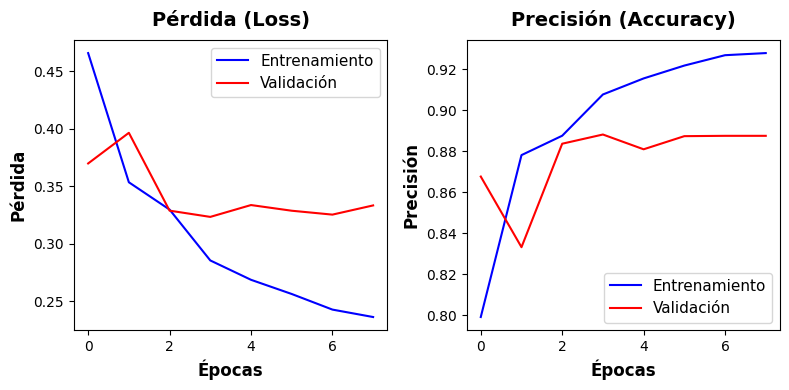

Generando predicciones en el conjunto de Test...


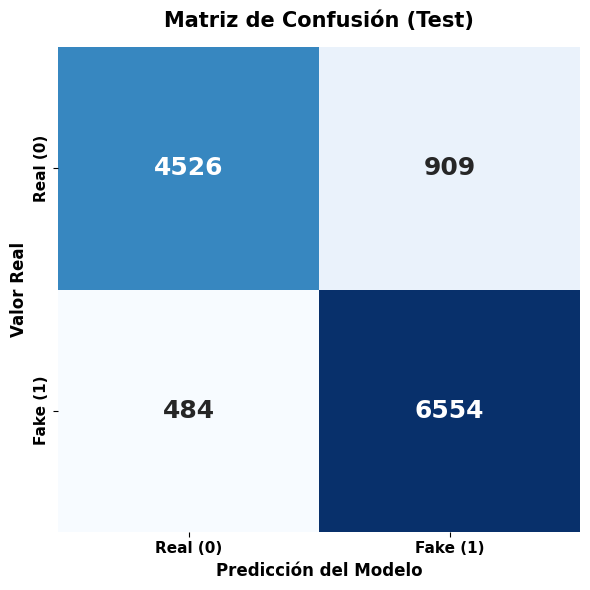

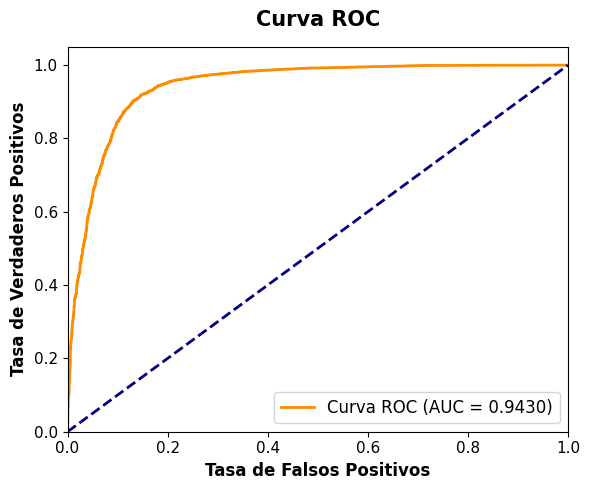


 REPORTE DE MÉTRICAS EN TEST 
              precision    recall  f1-score   support

    Real (0)       0.90      0.83      0.87      5435
    Fake (1)       0.88      0.93      0.90      7038

    accuracy                           0.89     12473
   macro avg       0.89      0.88      0.89     12473
weighted avg       0.89      0.89      0.89     12473

Área Bajo la Curva ROC (AUC): 0.9430

✅ Todas las gráficas y métricas se han guardado en la carpeta 'metricas/'.


In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Crear directorio para almacenar las métricas
os.makedirs('metricas', exist_ok=True)

# 1. Gráficas de Pérdida (Loss) y Precisión (Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Curva de Loss
ax1.plot(history.history['loss'], label='Entrenamiento', color='blue')
ax1.plot(history.history['val_loss'], label='Validación', color='red')
ax1.set_title('Pérdida (Loss)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Épocas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Pérdida', fontsize=12, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.legend(fontsize=11)

# Curva de Accuracy
ax2.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validación', color='red')
ax2.set_title('Precisión (Accuracy)', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Épocas', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precisión', fontsize=12, fontweight='bold')
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('metricas/loss_y_accuracy.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. Predicciones sobre el conjunto de Test
print("Generando predicciones en el conjunto de Test...")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 18, "weight": "bold"}, 
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Matriz de Confusión (Test)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('metricas/matriz_confusion.png', bbox_inches='tight', dpi=300)
plt.show()

# 4. Cálculo del AUC-ROC y Gráfica de la Curva ROC
auc_score = roc_auc_score(y_test, y_pred_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12, fontweight='bold')
plt.title('Curva ROC', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('metricas/curva_roc.png', bbox_inches='tight', dpi=300)
plt.show()

# 5. Métricas de Clasificación
print("\n" + "="*50)
print(" REPORTE DE MÉTRICAS EN TEST ")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=['Real (0)', 'Fake (1)']))
print(f"Área Bajo la Curva ROC (AUC): {auc_score:.4f}")

# 6. Guardar las métricas en un CSV
reporte_dict = classification_report(y_test, y_pred_classes, target_names=['Real (0)', 'Fake (1)'], output_dict=True)
df_metricas = pd.DataFrame(reporte_dict).transpose()

# Añadir métricas globales adicionales al DataFrame
df_metricas.loc['AUC-ROC', 'score'] = auc_score
# Añadimos el tiempo total en segundos (asegúrate de haber ejecutado la celda de entrenamiento antes)
if 'tiempo_total' in locals() or 'tiempo_total' in globals():
    df_metricas.loc['Tiempo Entrenamiento (segundos)', 'score'] = round(tiempo_total, 2)
else:
    print("⚠️ No se encontró la variable 'tiempo_total'. Asegúrate de ejecutar la celda de entrenamiento primero.")

# Guardar en CSV asegurando codificación para acentos en español
df_metricas.to_csv('metricas/reporte_metricas_Bidireccional_LSTM.csv', index=True, encoding='utf-8-sig')

print("\n✅ Todas las gráficas y métricas se han guardado en la carpeta 'metricas/'.")

## **10. Guardado de Artefactos**

In [47]:
import pickle
import os

# Crear directorio para almacenar los archivos
os.makedirs('artefactos', exist_ok=True)

# 1. Guardar el Tokenizador (Obligatorio para nuevos textos)
tokenizer_path = 'artefactos/tokenizer_fakenews.pkl'
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✅ Tokenizador guardado en: {tokenizer_path}")

# 2. Guardar el modelo completo (Arquitectura, pesos y estado del optimizador)
# Nota: Si usaste ModelCheckpoint, ya tienes el "mejor", pero aquí guardas el estado final
model_path = 'artefactos/modelo_bilstm_final.keras'
model.save(model_path)
print(f"✅ Modelo final guardado en: {model_path}")

# 3. Guardar metadatos de configuración (Útil para el script de inferencia)
metadata_path = 'artefactos/pipeline_config.pkl'
config = {
    'MAX_LEN': MAX_LEN,
    'MAX_VOCAB': MAX_VOCAB,
    'EMBED_DIM': EMBED_DIM
}
with open(metadata_path, 'wb') as f:
    pickle.dump(config, f)
print(f"✅ Configuración del pipeline guardada en: {metadata_path}")

print("\n🚀 ¡Pipeline finalizado! Los artefactos están listos para ser desplegados.")

✅ Tokenizador guardado en: artefactos/tokenizer_fakenews.pkl
✅ Modelo final guardado en: artefactos/modelo_bilstm_final.keras
✅ Configuración del pipeline guardada en: artefactos/pipeline_config.pkl

🚀 ¡Pipeline finalizado! Los artefactos están listos para ser desplegados.


## **11. Inferencia**

In [48]:
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Cargar los artefactos guardados
ruta_modelo = 'artefactos/modelo_bilstm_final.keras'
ruta_tokenizer = 'artefactos/tokenizer_fakenews.pkl'
ruta_config = 'artefactos/pipeline_config.pkl'

modelo_prod = load_model(ruta_modelo)

with open(ruta_tokenizer, 'rb') as f:
    tokenizer_prod = pickle.load(f)

with open(ruta_config, 'rb') as f:
    config_prod = pickle.load(f)

print("✅ Artefactos de producción cargados correctamente.")

# 2. Función de inferencia
def predecir_noticia(texto, modelo, tokenizador, max_len):
    """
    Toma un texto crudo, lo procesa y devuelve si es Real o Fake.
    Nota: En un caso real, debes aplicar a 'texto' la misma función
    'clean_for_dl' que usaste en el preprocesamiento inicial.
    """
    # Pasamos el texto a una lista (el tokenizer espera un iterable de textos)
    textos = [texto]
    
    # Transformación matemática
    secuencias = tokenizador.texts_to_sequences(textos)
    X_pred = pad_sequences(secuencias, maxlen=max_len, padding='post', truncating='post')
    
    # Predicción
    probabilidad = modelo.predict(X_pred, verbose=0)[0][0]
    
    # Clasificación
    es_fake = probabilidad > 0.5
    etiqueta = "Fake News 🚨" if es_fake else "Noticia Real ✅"
    confianza = probabilidad if es_fake else (1 - probabilidad)
    
    return etiqueta, confianza

# 3. Prueba con textos nuevos
textos_prueba = [
    "Urgente: El gobierno planea confiscar todos los ahorros de los ciudadanos mañana mediante un decreto secreto.",
    "España ganó el mundial en 2010."
]

print("\n--- TEST DE INFERENCIA ---")
for i, noticia in enumerate(textos_prueba, 1):
    print(f"\nNoticia {i}: '{noticia}'")
    etiqueta, confianza = predecir_noticia(
        texto=noticia, 
        modelo=modelo_prod, 
        tokenizador=tokenizer_prod, 
        max_len=config_prod['MAX_LEN']
    )
    print(f"Predicción: {etiqueta} (Confianza del modelo: {confianza:.2%})")

✅ Artefactos de producción cargados correctamente.

--- TEST DE INFERENCIA ---

Noticia 1: 'Urgente: El gobierno planea confiscar todos los ahorros de los ciudadanos mañana mediante un decreto secreto.'
Predicción: Fake News 🚨 (Confianza del modelo: 85.12%)

Noticia 2: 'España ganó el mundial en 2010.'
Predicción: Fake News 🚨 (Confianza del modelo: 54.40%)


## **12. Explicabilidad del Modelo (XAI con LIME)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from lime.lime_text import LimeTextExplainer

# 1. Función puente para conectar la BiLSTM con LIME
def predictor_lime(textos):
    secuencias = tokenizer_prod.texts_to_sequences(textos)
    X_pred = pad_sequences(secuencias, maxlen=config_prod['MAX_LEN'], padding='post', truncating='post')
    
    filas_vacias = np.where(~X_pred.any(axis=1))[0]
    if len(filas_vacias) > 0:
        X_pred[filas_vacias, 0] = 1 

    probs_fake = modelo_prod.predict(X_pred, verbose=0)
    probs_real = 1.0 - probs_fake
    return np.hstack((probs_real, probs_fake))

# 2. Inicializar el explicador LIME
explainer = LimeTextExplainer(class_names=['Real (0)', 'Fake (1)'])

# 3. Seleccionar el texto a explicar
texto_xai = textos_prueba[0]

# CALCULAR Y MOSTRAR LA PREDICCIÓN EXACTA 
probs = predictor_lime([texto_xai])[0] 
es_fake = probs[1] > 0.5
etiqueta_pred = "Fake News 🚨" if es_fake else "Noticia Real ✅"
confianza_pred = probs[1] if es_fake else probs[0]

print(f"\nNoticia analizada:\n'{texto_xai}'")
print("-" * 50)
print(f"🎯 PREDICCIÓN DEL MODELO: {etiqueta_pred}")
print(f"📊 CONFIANZA: {confianza_pred:.2%}")
print("-" * 50)

# 4. Generar la explicación (top 10 palabras)
explicacion = explainer.explain_instance(texto_xai, predictor_lime, num_features=10)

# 5. Visualizar la gráfica con colores y título de predicción
lista_pesos = explicacion.as_list()
palabras = [x[0] for x in lista_pesos][::-1]
pesos = [x[1] for x in lista_pesos][::-1]

# Asignar color: Rojo si empuja hacia Fake (positivo), Verde si empuja a Real (negativo)
colores = ['red' if peso > 0 else 'green' for peso in pesos]

plt.figure(figsize=(8, 6))
plt.barh(palabras, pesos, color=colores)

# Añadimos la predicción al título indicando que es la BiLSTM
titulo = f"Importancia de palabras (BiLSTM)\nPredicción: {etiqueta_pred} ({confianza_pred:.1%})"
plt.title(titulo, fontweight='bold', pad=15)

plt.xlabel('Peso (Izquierda/Verde = Real, Derecha/Rojo = Fake)')
plt.tight_layout()

# Guardar la gráfica en la carpeta
os.makedirs('xai', exist_ok=True)
plt.savefig('xai/prediccion_xai_bilstm.png', dpi=300)
plt.show()

# 6. Mostrar el resultado interactivo
try:
    explicacion.show_in_notebook(text=True)
except:
    pass